In [14]:
# step 1 # load and explore the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

In [15]:

file_path = "../data/train.txt"

triples = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # skip empty lines
            head, relation, tail = line.split()
            triples.append((head, relation, tail))
print(f"Total triples loaded: {len(triples)}")

Total triples loaded: 13821


In [16]:
df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
df.head()

,head,relation,tail
0,olivia0,sisterOf,selina10
1,olivia0,sisterOf,isabella11
2,olivia0,sisterOf,oskar24
3,olivia0,sisterOf,adam9
4,olivia0,secondAuntOf,lena18


In [17]:
entities = pd.unique(df[["head", "tail"]].values.ravel())

len(entities)


1316

In [18]:

relations = pd.unique(df["relation"].values.ravel())
len(relations)

28

In [19]:
unique_nodes = pd.unique(df[["head", "tail"]].values.ravel())
unique_nodes = unique_nodes.tolist()
len(unique_nodes), unique_nodes[:10]
# print(f"Total unique entities: {len(unique_nodes)}")

(1316,
 ['olivia0',
  'selina10',
  'isabella11',
  'oskar24',
  'adam9',
  'lena18',
  'fabian26',
  'leon16',
  'johanna22',
  'jonas23'])

In [20]:
# Count occurrences of each relation
relation_counts = df["relation"].value_counts()

# Convert to dictionary
relation_count_dict = relation_counts.to_dict()

# Inspect
relation_count_dict


{'grandsonOf': 814,
 'grandmotherOf': 813,
 'grandfatherOf': 813,
 'granddaughterOf': 812,
 'motherOf': 733,
 'fatherOf': 733,
 'sisterOf': 636,
 'daughterOf': 628,
 'greatGrandsonOf': 624,
 'greatGrandmotherOf': 617,
 'greatGrandfatherOf': 617,
 'greatGranddaughterOf': 610,
 'sonOf': 600,
 'brotherOf': 570,
 'auntOf': 556,
 'nephewOf': 514,
 'nieceOf': 496,
 'uncleOf': 454,
 'girlCousinOf': 445,
 'boyCousinOf': 391,
 'greatAuntOf': 312,
 'greatUncleOf': 237,
 'boyFirstCousinOnceRemovedOf': 180,
 'secondAuntOf': 175,
 'secondUncleOf': 158,
 'girlFirstCousinOnceRemovedOf': 153,
 'boySecondCousinOf': 68,
 'girlSecondCousinOf': 62}

In [21]:
relation_stats_df = relation_counts.reset_index()
relation_stats_df.columns = ["relation", "count"]

relation_stats_df


,relation,count
0,grandsonOf,814
1,grandmotherOf,813
2,grandfatherOf,813
3,granddaughterOf,812
4,motherOf,733
5,fatherOf,733
6,sisterOf,636
7,daughterOf,628
8,greatGrandsonOf,624
9,greatGrandmotherOf,617


In [26]:
print("Total triples:", len(df))
print("Unique number of people in the knowledge graph:", len(unique_nodes))
print("Unique relations:", len(relation_count_dict))



Total triples: 13821
Unique number of people in the knowledge graph: 1316
Unique relations: 28


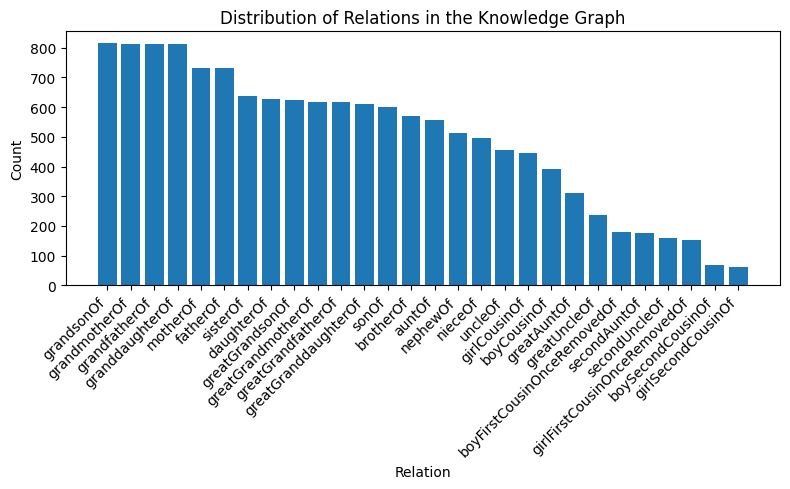

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    relation_stats_df["relation"],
    relation_stats_df["count"]
)

plt.xlabel("Relation")
plt.ylabel("Count")
plt.title("Distribution of Relations in the Knowledge Graph")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


In [24]:
G = nx.MultiDiGraph()
for _, row in df.iterrows():
    G.add_edge(
        row["head"],
        row["tail"],
        relation=row["relation"]
    )
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 1316 nodes and 13821 edges.


In [25]:
list(G.edges(data=True))[:5]


[('olivia0', 'selina10', {'relation': 'sisterOf'}),
 ('olivia0', 'isabella11', {'relation': 'sisterOf'}),
 ('olivia0', 'oskar24', {'relation': 'sisterOf'}),
 ('olivia0', 'adam9', {'relation': 'sisterOf'}),
 ('olivia0', 'lena18', {'relation': 'secondAuntOf'})]

In [27]:
# Relavant statistics about the knowledge graph
print("Total triples:", len(df))
print("Unique number of people in the knowledge graph:", len(unique_nodes))
print("Unique relations:", len(relation_count_dict))
# Additional statistics
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())

Total triples: 13821
Unique number of people in the knowledge graph: 1316
Unique relations: 28
Number of nodes in the graph: 1316
Number of edges in the graph: 13821


In [28]:
# Degree distribution
# List of tuples: (node_id, indegree, outdegree)
degree_tuples = [
    (node, G.in_degree(node), G.out_degree(node))
    for node in G.nodes()
]

# Inspect first few
degree_tuples[:10]


[('olivia0', 19, 20),
 ('selina10', 21, 21),
 ('isabella11', 21, 21),
 ('oskar24', 21, 21),
 ('adam9', 21, 21),
 ('lena18', 20, 17),
 ('fabian26', 20, 17),
 ('leon16', 19, 19),
 ('johanna22', 19, 19),
 ('jonas23', 17, 19)]

In [29]:
import pandas as pd

degree_df = pd.DataFrame(
    degree_tuples,
    columns=["node_id", "in_degree", "out_degree"]
)

degree_df.head()


,node_id,in_degree,out_degree
0,olivia0,19,20
1,selina10,21,21
2,isabella11,21,21
3,oskar24,21,21
4,adam9,21,21


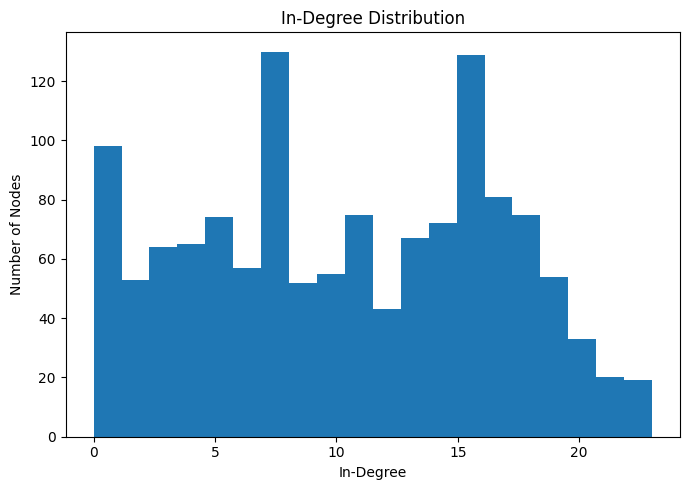

In [30]:
plt.figure(figsize=(7, 5))

plt.hist(degree_df["in_degree"], bins=20)

plt.xlabel("In-Degree")
plt.ylabel("Number of Nodes")
plt.title("In-Degree Distribution")

plt.tight_layout()
plt.show()


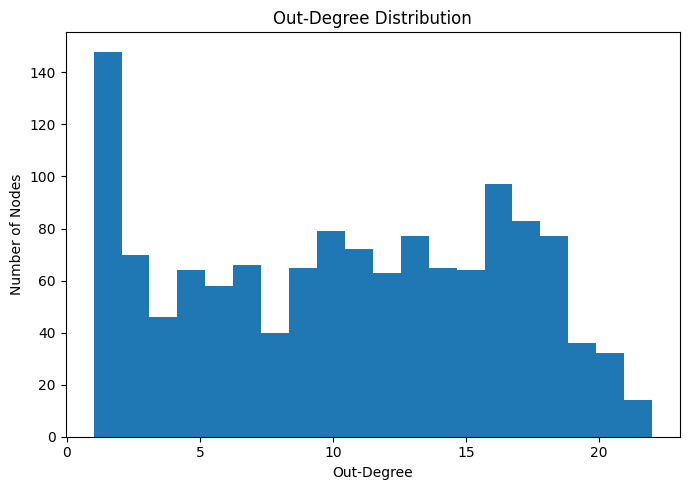

In [31]:
plt.figure(figsize=(7, 5))

plt.hist(degree_df["out_degree"], bins=20)

plt.xlabel("Out-Degree")
plt.ylabel("Number of Nodes")
plt.title("Out-Degree Distribution")

plt.tight_layout()
plt.show()


In [37]:
in_degree_mean = degree_df["in_degree"].mean()
in_degree_median = degree_df["in_degree"].median()
in_degree_mode = degree_df["in_degree"].mode().tolist()  # can be multiple
in_degree_max = degree_df["in_degree"].max()

print("In-Degree Statistics")
print("Mean:", in_degree_mean)
print("Median:", in_degree_median)
print("Mode(s):", in_degree_mode)
print("Max:", in_degree_max)


In-Degree Statistics
Mean: 10.50227963525836
Median: 11.0
Mode(s): [1]
Max: 23


In [38]:
out_degree_mean = degree_df["out_degree"].mean()
out_degree_median = degree_df["out_degree"].median()
out_degree_mode = degree_df["out_degree"].mode().tolist()  # can be multiple
out_degree_max = degree_df["out_degree"].max()

print("Out-Degree Statistics")
print("Mean:", out_degree_mean)
print("Median:", out_degree_median)
print("Mode(s):", out_degree_mode)
print("Max:", out_degree_max)

Out-Degree Statistics
Mean: 10.50227963525836
Median: 11.0
Mode(s): [16]
Max: 22


In [ ]:
k = 5  # we can change k as needed

topk_in_degree = degree_df.sort_values(
    by="in_degree", ascending=False
).head(k)

topk_in_degree


,node_id,in_degree,out_degree
1032,dominik1036,23,22
1036,oliver1045,23,22
1040,lisa1035,23,22
1035,magdalena1044,23,22
644,valentin638,22,20


In [36]:
l = 5  # we can change l as needed
topk_out_degree = degree_df.sort_values(
    by="out_degree", ascending=False
).head(l)

topk_out_degree


,node_id,in_degree,out_degree
139,fabian140,22,22
138,larissa136,22,22
137,oskar133,22,22
154,laura143,20,22
1032,dominik1036,23,22


In [39]:
# Doing stats on each family by calculating connected components

# Get weakly connected components (each ≈ one family)
components = list(nx.weakly_connected_components(G))

# Number of families
num_families = len(components)
num_families


50

In [40]:
# Dictionary: {family_id: family_size}
family_size_dict = {
    idx: len(component)
    for idx, component in enumerate(components)
}

family_size_dict


{0: 27,
 1: 26,
 2: 26,
 3: 26,
 4: 26,
 5: 27,
 6: 26,
 7: 27,
 8: 26,
 9: 26,
 10: 26,
 11: 26,
 12: 26,
 13: 27,
 14: 26,
 15: 26,
 16: 26,
 17: 26,
 18: 27,
 19: 26,
 20: 27,
 21: 26,
 22: 26,
 23: 26,
 24: 26,
 25: 26,
 26: 26,
 27: 27,
 28: 26,
 29: 26,
 30: 27,
 31: 27,
 32: 27,
 33: 26,
 34: 27,
 35: 26,
 36: 26,
 37: 27,
 38: 26,
 39: 27,
 40: 26,
 41: 26,
 42: 26,
 43: 27,
 44: 26,
 45: 27,
 46: 26,
 47: 27,
 48: 26,
 49: 26}

In [45]:
family_size_df = pd.DataFrame(
    list(family_size_dict.items()),
    columns=["family_id", "family_size"]
)

family_size_df.head()

,family_id,family_size
0,0,27
1,1,26
2,2,26
3,3,26
4,4,26


In [46]:
family_size_stats = {
    "mean": family_size_df["family_size"].mean(),
    "median": family_size_df["family_size"].median(),
    "mode": family_size_df["family_size"].mode().tolist(),  # can be multiple
    "max": family_size_df["family_size"].max(),
    "min": family_size_df["family_size"].min()
}

family_size_stats


{'mean': np.float64(26.32),
 'median': np.float64(26.0),
 'mode': [26],
 'max': np.int64(27),
 'min': np.int64(26)}

In [44]:
summary_family_size_df = pd.DataFrame(
    list(family_size_stats.items()),
    columns=["statistic", "value"]
)

summary_family_size_df


,statistic,value
0,mean,26.32
1,median,26.0
2,mode,[26]
3,max,27
4,min,26


In [47]:
# Families with maximum size
families_max_size = family_size_df[
    family_size_df["family_size"] == family_size_stats["max"]
]

# Families with minimum size
families_min_size = family_size_df[
    family_size_df["family_size"] == family_size_stats["min"]
]

families_max_size, families_min_size


(    family_id  family_size
 0           0           27
 5           5           27
 7           7           27
 13         13           27
 18         18           27
 20         20           27
 27         27           27
 30         30           27
 31         31           27
 32         32           27
 34         34           27
 37         37           27
 39         39           27
 43         43           27
 45         45           27
 47         47           27,
     family_id  family_size
 1           1           26
 2           2           26
 3           3           26
 4           4           26
 6           6           26
 8           8           26
 9           9           26
 10         10           26
 11         11           26
 12         12           26
 14         14           26
 15         15           26
 16         16           26
 17         17           26
 19         19           26
 21         21           26
 22         22           26
 23         23     

In [48]:
# Population variance (treating your dataset as the full population)
family_size_variance = family_size_df["family_size"].var(ddof=0)

family_size_variance


np.float64(0.2176)

In [ ]:
# Sample variance (default in pandas)
family_size_sample_variance = family_size_df["family_size"].var() # ddof = 1 default in pandas for sample variance
 
family_size_sample_variance


np.float64(0.22204081632653058)

In [54]:
family_size_std = family_size_df["family_size"].std(ddof=0)

family_size_std



np.float64(0.466476151587624)

In [ ]:
# Sample standard deviation (default in pandas)
family_size_sample_std = family_size_df["family_size"].std() # ddof = 1 default in pandas for sample std
family_size_sample_std

np.float64(0.47121207149916117)

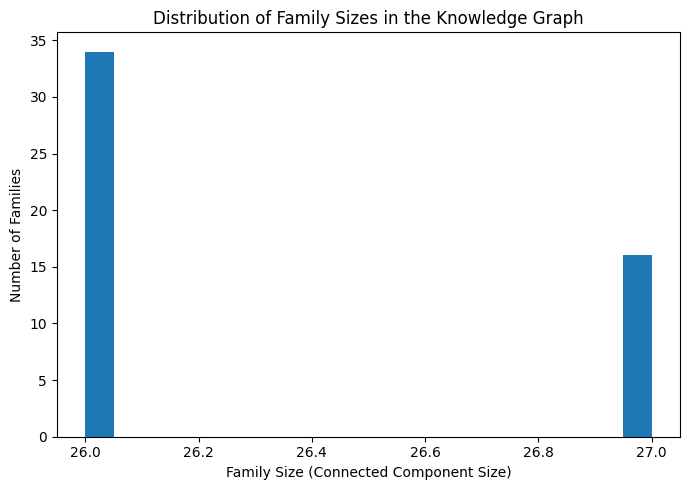

In [59]:
plt.figure(figsize=(7, 5))

plt.hist(
    family_size_df["family_size"],
    bins=20
)

plt.xlabel("Family Size (Connected Component Size)")
plt.ylabel("Number of Families")
plt.title("Distribution of Family Sizes in the Knowledge Graph")

plt.tight_layout()
plt.show()


In [ ]:
family_size_df.sort_values(by="family_size", ascending=False).head(10)

,family_id,family_size
0,0,27
5,5,27
13,13,27
7,7,27
31,31,27
30,30,27
45,45,27
47,47,27
39,39,27
43,43,27


In [61]:
# centrality measures
degree_centrality_records = []
betweenness_centrality_records = []

for family_id, nodes in enumerate(components):
    # Extract subgraph for this family
    subgraph = G.subgraph(nodes)
    
    # Convert to undirected simple graph
    undirected_subgraph = nx.Graph(subgraph)
    
    # Compute centralities
    deg_cent = nx.degree_centrality(undirected_subgraph)
    bet_cent = nx.betweenness_centrality(undirected_subgraph)
    
    # Store degree centrality
    for node, value in deg_cent.items():
        degree_centrality_records.append(
            (family_id, node, value)
        )
    
    # Store betweenness centrality
    for node, value in bet_cent.items():
        betweenness_centrality_records.append(
            (family_id, node, value)
        )


In [62]:
degree_centrality_df = pd.DataFrame(
    degree_centrality_records,
    columns=["family_id", "node_id", "degree_centrality"]
)

degree_centrality_df.head()


,family_id,node_id,degree_centrality
0,0,lisa5,0.846154
1,0,oliver3,0.115385
2,0,moritz8,0.653846
3,0,david20,0.346154
4,0,valentina25,0.038462


In [63]:
betweenness_centrality_df = pd.DataFrame(
    betweenness_centrality_records,
    columns=["family_id", "node_id", "betweenness_centrality"]
)

betweenness_centrality_df.head()


,family_id,node_id,betweenness_centrality
0,0,lisa5,0.04142
1,0,oliver3,0.00000
2,0,moritz8,0.00000
3,0,david20,0.00000
4,0,valentina25,0.00000


In [64]:
centrality_df = pd.merge(
    degree_centrality_df,
    betweenness_centrality_df,
    on=["family_id", "node_id"],
    how="inner"
)

centrality_df.head()


,family_id,node_id,degree_centrality,betweenness_centrality
0,0,lisa5,0.846154,0.04142
1,0,oliver3,0.115385,0.00000
2,0,moritz8,0.653846,0.00000
3,0,david20,0.346154,0.00000
4,0,valentina25,0.038462,0.00000
